In [158]:
import os
import json
import pytz
import signal
import threading
import websocket
import math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone
import alpaca_trade_api as tradeapi
from alpaca_trade_api.rest import TimeFrame

API_KEY    = "PKVFX17VIP19CWGQPOBN"
SECRET_KEY = "SG0MX5gJ3LwnGt9LasXYUbVywCZ7SH4slJkXqPZl"
BASE_URL   = "https://paper-api.alpaca.markets" # Paper 环境
WS_URL     = "wss://stream.data.alpaca.markets/v2/iex"  # IEX 免费实时流
FEED       = "iex"

api = tradeapi.REST(API_KEY, SECRET_KEY, BASE_URL, api_version="v2")
account = api.get_account()

## 账户信息显示

In [34]:
eq = float(account.equity or 0)
last_eq = float(account.last_equity or eq)
today_pl = eq - last_eq
today_plpc = (today_pl / last_eq * 100) if last_eq else 0.0

print("== Account Info ==")
print("ID:", account.id)
print("Status:", account.status)
print("Cash:", account.cash)
print("Buying Power:", account.buying_power)
print("Portfolio Value:", account.portfolio_value)
print(f"Today's P/L: {today_pl:.2f} ({today_plpc:.2f}%)")

positions = api.list_positions()
print("\n== Positions ==")
if not positions:
    print("No open positions")
else:
    for p in positions:
        print(f"{p.symbol}: qty={p.qty}, avg_entry_price={p.avg_entry_price}, "
              f"current_price={p.current_price}, unrealized_pl={p.unrealized_pl}")

== Account Info ==
ID: 11ea625e-497d-4144-b022-26c8535144fe
Status: ACTIVE
Cash: 100000
Buying Power: 200000
Portfolio Value: 100000
Today's P/L: 0.00 (0.00%)

== Positions ==
No open positions


## 下单

### 1.单股普通下单

In [48]:
# ==== 订单参数（按需修改）====
SYMBOL = "AAPL"
QTY    = 1
SIDE   = "buy"          # 或 "sell"
TYPE   = "market"       # 也可用 "limit" 并加 limit_price
TIF    = "day"          # time_in_force: "day"/"gtc"/"fok"/"ioc"/"opg"/"cls" 等
POLL_SEC = 1
TIMEOUT  = 60

def account_snapshot():
    acc = api.get_account()
    eq = float(acc.equity or 0.0); last = float(acc.last_equity or eq)
    pl = eq - last; plpc = (pl/last*100) if last else 0.0
    print("\n== Account ==")
    print("Status:", acc.status, "| Cash:", acc.cash, "| BuyingPower:", acc.buying_power)
    print("Equity:", acc.equity,  "| Today P/L: %.2f (%.2f%%)" % (pl, plpc))

def positions_snapshot():
    poss = api.list_positions()
    print("\n== Positions ==")
    if not poss:
        print("No open positions")
    else:
        for p in poss:
            print(f"{p.symbol}: qty={p.qty}, avg={p.avg_entry_price}, "
                  f"px={p.current_price}, uPnL={p.unrealized_pl}")

def place_and_wait():
    print(f"\nPlacing order: {SIDE} {QTY} {SYMBOL} @ {TYPE}/{TIF} ...")
    order = api.submit_order(symbol=SYMBOL, qty=QTY, side=SIDE, type=TYPE, time_in_force=TIF)
    oid = order.id
    start = time.time()
    terminal = {"filled", "canceled", "rejected", "expired"}

    while True:
        o = api.get_order(oid)
        if o.status in terminal:
            print(f"Order {o.status} • filled_qty={o.filled_qty} • avg_fill_price={o.filled_avg_price}")
            if o.status != "filled":
                print("Reason:", o.status)
            return o
        if time.time() - start > TIMEOUT:
            print("Timeout → canceling...")
            try:
                api.cancel_order(oid)
            except Exception as e:
                print("Cancel failed:", e)
            return o
        time.sleep(POLL_SEC)

if __name__ == "__main__":
    account_snapshot()
    positions_snapshot()
    place_and_wait()
    positions_snapshot()
    account_snapshot()


== Account ==
Status: ACTIVE | Cash: 100000 | BuyingPower: 199487.54
Equity: 100000 | Today P/L: 0.00 (0.00%)

== Positions ==
No open positions

Placing order: buy 1 AAPL @ market/day ...
Timeout → canceling...

== Positions ==
No open positions

== Account ==
Status: ACTIVE | Cash: 100000 | BuyingPower: 199487.54
Equity: 100000 | Today P/L: 0.00 (0.00%)


### 2.多股普通下单

In [69]:
# === 多单定义：按需增删 ===
ORDERS = [
    {"symbol": "AAPL", "qty": 1, "side": "buy",  "type": "market", "tif": "day"},
    {"symbol": "MSFT", "qty": 1, "side": "buy",  "type": "market", "tif": "day"},
    {"symbol": "NVDA", "qty": 1, "side": "buy",  "type": "market", "tif": "day"},
    # {"symbol": "AAPL", "qty": 1, "side": "sell", "type": "market", "tif": "day"},
]

POLL_SEC = 1
TIMEOUT  = 60


def place_and_wait_one(order):
    symbol = order["symbol"]; qty = order["qty"]; side = order["side"]
    typ    = order.get("type", "market"); tif = order.get("tif", "day")
    print(f"\nPlacing: {side} {qty} {symbol} @ {typ}/{tif} ...")
    o = api.submit_order(symbol=symbol, qty=qty, side=side, type=typ, time_in_force=tif)
    oid = o.id
    start = time.time()
    terminal = {"filled", "canceled", "rejected", "expired"}
    while True:
        cur = api.get_order(oid)
        if cur.status in terminal:
            print(f"→ {symbol} {cur.status} • filled={cur.filled_qty} • avg={cur.filled_avg_price}")
            if cur.status != "filled":
                print("  Reason:", cur.status)
            return cur
        if time.time() - start > TIMEOUT:
            print(f"→ {symbol} timeout, canceling…")
            try: api.cancel_order(oid)
            except Exception as e: print("  Cancel failed:", e)
            return api.get_order(oid)
        time.sleep(POLL_SEC)

if __name__ == "__main__":
    account_snapshot()
    positions_snapshot()
    for od in ORDERS:
        place_and_wait_one(od)
    positions_snapshot()
    account_snapshot()


== Account ==
Status: ACTIVE | Cash: 100000 | BuyingPower: 199487.54
Equity: 100000 | Today P/L: 0.00 (0.00%)

== Positions ==
No open positions

Placing: buy 1 AAPL @ market/day ...
→ AAPL timeout, canceling…

Placing: buy 1 MSFT @ market/day ...
→ MSFT timeout, canceling…

Placing: buy 1 NVDA @ market/day ...
→ NVDA timeout, canceling…

== Positions ==
No open positions

== Account ==
Status: ACTIVE | Cash: 100000 | BuyingPower: 199487.54
Equity: 100000 | Today P/L: 0.00 (0.00%)


## 回测

### 1. 数据下载

#### （1） 历史数据下载

In [124]:
SYMBOL        = "AAPL"
TF            = TimeFrame.Minute   # 可选：Minute / Hour / Day
LOOKBACK_DAYS = 2
FEED       = "iex"

def _to_rfc3339_z(dt: datetime) -> str:
    return dt.astimezone(timezone.utc).replace(microsecond=0).isoformat().replace("+00:00","Z")

def fetch_history(symbol: str) -> pd.DataFrame:
    end_dt   = datetime.now(timezone.utc).replace(microsecond=0)
    start_dt = end_dt - timedelta(days=LOOKBACK_DAYS)
    start_str, end_str = _to_rfc3339_z(start_dt), _to_rfc3339_z(end_dt)

    bars = api.get_bars(symbol, TF, start=start_str, end=end_str,
                        adjustment="raw", feed=FEED).df

    if bars.empty:
        return pd.DataFrame(columns=["time","open","high","low","close","volume"]).set_index(
            pd.DatetimeIndex([], name="time")
        )

    df = (bars.reset_index()[["timestamp","open","high","low","close","volume"]]
               .rename(columns={"timestamp":"time"})
               .set_index("time")
               .sort_index())
    return df

if __name__ == "__main__":
    hist = fetch_history(SYMBOL)
    print("=== Historical Data ===")
    print(hist.tail(5))

=== Historical Data ===
                              open     high     low    close  volume
time                                                                
2025-09-25 19:55:00+00:00  256.150  256.360  256.03  256.310   11835
2025-09-25 19:56:00+00:00  256.320  256.525  256.31  256.525   10208
2025-09-25 19:57:00+00:00  256.530  256.700  256.53  256.650   16826
2025-09-25 19:58:00+00:00  256.660  256.840  256.66  256.840   17713
2025-09-25 19:59:00+00:00  256.855  256.975  256.83  256.910   24215


#### （2） 实时数据下载

In [128]:
WS_URL = "wss://stream.data.alpaca.markets/v2/iex"

class AlpacaWS:
    def __init__(self, url: str, key: str, secret: str, symbol: str):
        self.url = url
        self.key = key
        self.secret = secret
        self.symbol = symbol
        self.ws = None

    def on_open(self, ws):
        ws.send(json.dumps({"action": "auth", "key": self.key, "secret": self.secret}))
        ws.send(json.dumps({"action": "subscribe","trades":[self.symbol],"bars":[self.symbol]}))
        print(f"[WS] Opened & Subscribed: {self.symbol}")

    def on_message(self, ws, message):
        data = json.loads(message)
        for evt in data:
            if evt.get("T") == "t":
                print(f"[Trade] {evt['S']} px={evt['p']} ts={evt['t']}")
            elif evt.get("T") == "b":
                print(f"[Bar]   {evt['S']} o={evt['o']} h={evt['h']} "
                      f"l={evt['l']} c={evt['c']} v={evt['v']} t={evt['t']}")
            elif evt.get("T") == "success":
                print("[WS] success:", evt.get("msg"))
            elif evt.get("T") == "subscription":
                print("[WS] subscribed:", evt)
            else:
                print("[WS] evt:", evt)

    def on_error(self, ws, error): print("[WS] error:", error)
    def on_close(self, ws, code, msg): print(f"[WS] closed code={code} msg={msg}")

    def run(self):
        self.ws = websocket.WebSocketApp(
            self.url,
            on_open=self.on_open,
            on_message=self.on_message,
            on_error=self.on_error,
            on_close=self.on_close
        )
        self.ws.run_forever(ping_interval=20, ping_timeout=10)

    def stop(self):
        if self.ws: self.ws.close()

if __name__ == "__main__":
    client = AlpacaWS(WS_URL, API_KEY, SECRET_KEY, SYMBOL)
    t = threading.Thread(target=client.run, daemon=True)
    t.start()

    RUN_SECONDS = 60
    def handle_sigint(sig, frame):
        print("\n[Main] SIGINT received. Closing WS...")
        client.stop()
        time.sleep(1); raise SystemExit(0)
    signal.signal(signal.SIGINT, handle_sigint)

    elapsed = 0
    while elapsed < RUN_SECONDS:
        time.sleep(1); elapsed += 1

    print("\n[Main] Time up. Closing WS...")
    client.stop()

[WS] Opened & Subscribed: AAPL
[WS] success: connected
[WS] success: authenticated
[WS] subscribed: {'T': 'subscription', 'trades': ['AAPL'], 'bars': ['AAPL'], 'corrections': ['AAPL'], 'cancelErrors': ['AAPL']}

[Main] Time up. Closing WS...
[WS] closed code=None msg=None


### 2.策略执行

#### (1）均线交易法

##### 1.1 单股

In [150]:
# === 策略参数 ===
FAST, SLOW = 20, 50  # 20/50 均线交叉

def build_signals(df_prices: pd.DataFrame, fast: int = FAST, slow: int = SLOW) -> pd.Series:
    """基于收盘价计算 T+1 生效的仓位信号（0/1），用于回测避免前视。"""
    prices  = df_prices["close"].astype(float)
    fast_ma = prices.rolling(fast).mean()
    slow_ma = prices.rolling(slow).mean()
    sig = (fast_ma > slow_ma).astype(int)
    return sig.shift(1).fillna(0)  # T+1 生效

def apply_strategy(df_prices: pd.DataFrame, fast: int = FAST, slow: int = SLOW) -> dict:
    """返回价格、仓位与策略收益序列。"""
    prices = df_prices["close"].astype(float)
    pos    = build_signals(df_prices, fast, slow)
    ret    = prices.pct_change().fillna(0.0)
    strat  = (pos * ret).fillna(0.0)
    return {"prices": prices, "positions": pos, "strategy_returns": strat}

if __name__ == "__main__":
    from __main__ import fetch_history, SYMBOL  
    df = fetch_history(SYMBOL)
    if df.empty:
        print("No data returned.")
    else:
        out = apply_strategy(df)
        print("=== Signals (tail) ===")
        print(pd.concat([out["prices"], out["positions"]], axis=1).tail(10))

=== Signals (tail) ===
                             close  close
time                                     
2025-09-25 19:50:00+00:00  255.680    0.0
2025-09-25 19:51:00+00:00  255.580    0.0
2025-09-25 19:52:00+00:00  255.480    0.0
2025-09-25 19:53:00+00:00  255.510    0.0
2025-09-25 19:54:00+00:00  256.070    0.0
2025-09-25 19:55:00+00:00  256.310    0.0
2025-09-25 19:56:00+00:00  256.525    0.0
2025-09-25 19:57:00+00:00  256.650    0.0
2025-09-25 19:58:00+00:00  256.840    0.0
2025-09-25 19:59:00+00:00  256.910    0.0


#### (2）均线交易法

#### (3）均线交易法

### 3.策略表现

In [162]:
INITIAL_CAPITAL = 100000.0
TF = TimeFrame.Minute  

def periods_per_year(tf: TimeFrame) -> int:
    if tf == TimeFrame.Day:    return 252
    if tf == TimeFrame.Hour:   return 1638
    if tf == TimeFrame.Minute: return 390 * 252
    return 252

def compute_performance(df_prices: pd.DataFrame, tf: TimeFrame = TF) -> dict:
    from __main__ import apply_strategy
    out = apply_strategy(df_prices)
    prices, positions, strategy_returns = out["prices"], out["positions"], out["strategy_returns"]

    equity = (1.0 + strategy_returns).cumprod() * INITIAL_CAPITAL
    total_return = (equity.iloc[-1] / INITIAL_CAPITAL - 1.0) * 100.0

    py = periods_per_year(tf)
    ann_return = (equity.iloc[-1] / INITIAL_CAPITAL) ** (py / max(len(equity),1)) - 1.0
    ann_return *= 100.0

    vol = strategy_returns.std() * np.sqrt(py) * 100.0
    sharpe = 0.0
    denom = strategy_returns.std() * np.sqrt(py)
    if denom > 0:
        sharpe = (strategy_returns.mean() * py) / denom

    eq = equity / INITIAL_CAPITAL
    max_drawdown = ((eq / eq.cummax()) - 1.0).min() * 100.0

    trades = int(positions.diff().abs().fillna(0).gt(0).sum())
    buy_hold_return = (prices.iloc[-1] / prices.iloc[0] - 1.0) * 100.0

    return {
        "portfolio_value": equity,
        "returns": strategy_returns,      # ← 新增
        "positions": positions,           # ← 可选：给画仓位用
        "total_return": float(total_return),
        "annual_return": float(ann_return),
        "volatility": float(vol),
        "sharpe_ratio": float(sharpe),
        "max_drawdown": float(max_drawdown),
        "trade_count": trades,
        "buy_hold_return": float(buy_hold_return),
    }

def print_report(res: dict):
    print("\n=== 策略表现（分钟）===")
    print(f"初始资金: ${INITIAL_CAPITAL:,.0f}")
    print(f"最终资金: ${res['portfolio_value'].iloc[-1]:,.0f}")
    print(f"总收益率: {res['total_return']:.2f}%")
    print(f"年化收益率: {res['annual_return']:.2f}%")
    print(f"年化波动率: {res['volatility']:.2f}%")
    print(f"夏普比率: {res['sharpe_ratio']:.2f}")
    print(f"最大回撤: {res['max_drawdown']:.2f}%")
    print(f"交易次数: {res['trade_count']}")
    print(f"买入持有收益: {res['buy_hold_return']:.2f}%")

if __name__ == "__main__":
    from __main__ import fetch_history, SYMBOL 
    df = fetch_history(SYMBOL)
    if df.empty:
        print("No data.")
    else:
        res = compute_performance(df, TF)
        print_report(res)


=== 策略表现（分钟）===
初始资金: $100,000
最终资金: $100,025
总收益率: 0.02%
年化收益率: 3.17%
年化波动率: 13.17%
夏普比率: 0.30
最大回撤: -1.09%
交易次数: 18
买入持有收益: 0.77%


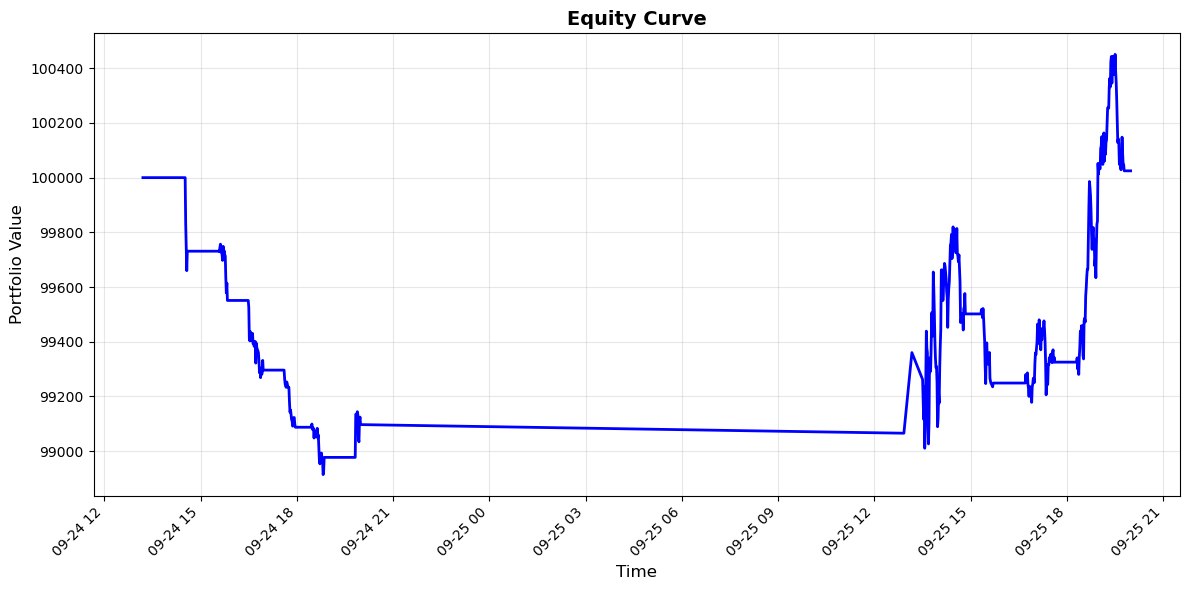

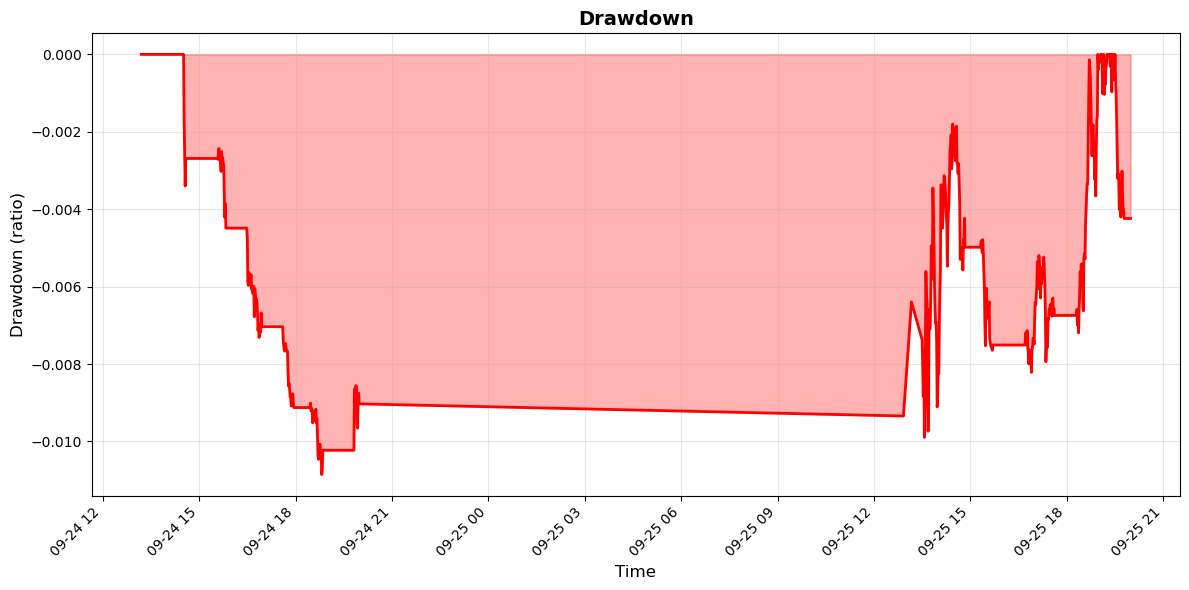

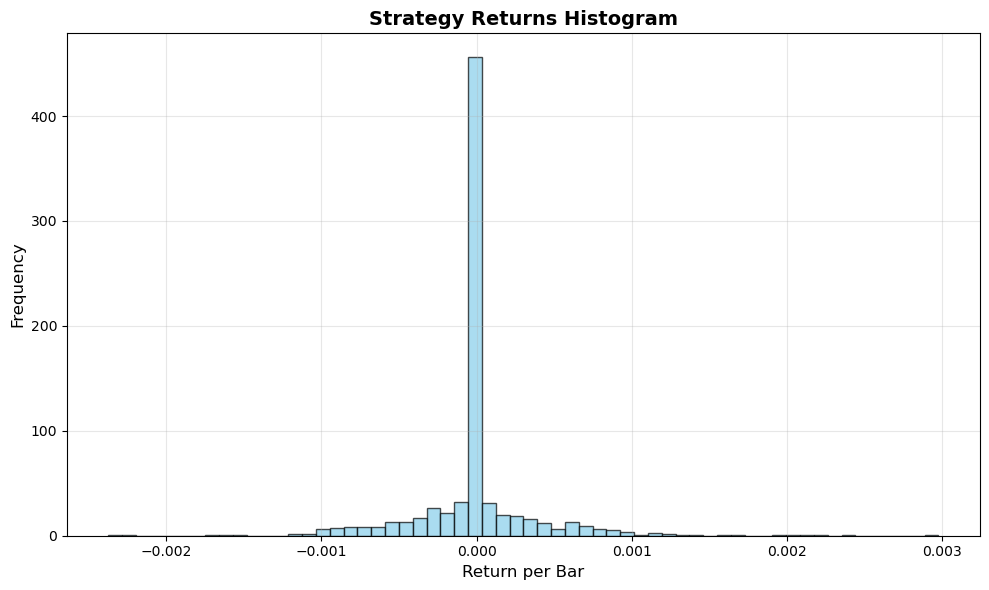

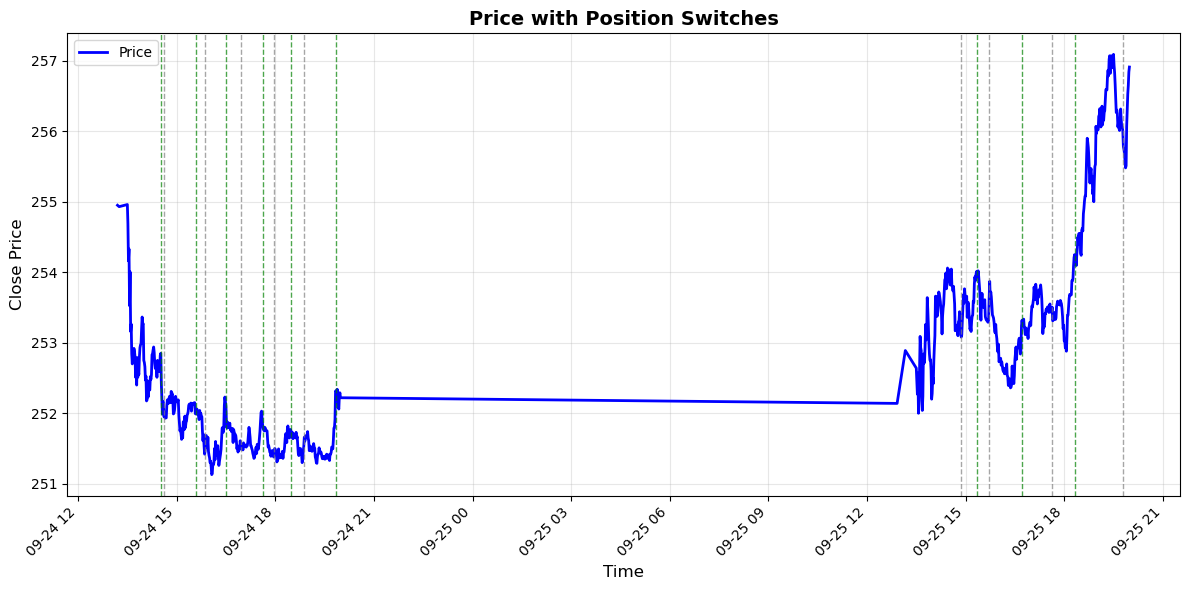

In [174]:
def compute_drawdown(equity: pd.Series) -> pd.Series:
    curve = equity / equity.iloc[0]
    peak = curve.cummax()
    dd = (curve / peak) - 1.0
    return dd

def plot_equity_curve(res: dict):
    eq = res["portfolio_value"]
    plt.figure(figsize=(12, 6))
    plt.plot(eq.index, eq.values, linewidth=2, color='blue')
    plt.title("Equity Curve", fontsize=14, fontweight='bold')
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Portfolio Value", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def plot_drawdown(res: dict):
    eq = res["portfolio_value"]
    dd = compute_drawdown(eq)
    plt.figure(figsize=(12, 6))
    plt.fill_between(dd.index, dd.values, 0, alpha=0.3, color='red')
    plt.plot(dd.index, dd.values, color='red', linewidth=2)
    plt.title("Drawdown", fontsize=14, fontweight='bold')
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Drawdown (ratio)", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def plot_returns_hist(res: dict, bins: int = 50):
    rets = res["returns"]
    plt.figure(figsize=(10, 6))
    plt.hist(rets.dropna().values, bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title("Strategy Returns Histogram", fontsize=14, fontweight='bold')
    plt.xlabel("Return per Bar", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_price_with_positions(df_prices: pd.DataFrame, positions: pd.Series):
    """
    单图展示：价格曲线 + 仓位切换点（用竖线标出切换时刻）
    说明：不使用多子图；竖线位置在 positions 发生变化的时刻。
    """
    prices = df_prices["close"].astype(float)
    change_idx = positions.diff().fillna(0).ne(0)
    switch_times = positions.index[change_idx]

    plt.figure(figsize=(12, 6))
    plt.plot(prices.index, prices.values, linewidth=2, color='blue', label='Price')
    
    # 添加仓位切换点
    for t in switch_times:
        color = 'green' if positions.loc[t] > 0 else 'red' if positions.loc[t] < 0 else 'gray'
        plt.axvline(t, linestyle="--", alpha=0.7, color=color, linewidth=1)
    
    plt.title("Price with Position Switches", fontsize=14, fontweight='bold')
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Close Price", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

# ===== =====
if __name__ == "__main__":
    # 1) 获取历史数据
    df = fetch_history(SYMBOL)
    if df.empty:
        print("No data.")
    else:
        # 2) 计算策略表现
        res = compute_performance(df, TF)

        # 3) 逐个图表展示
        plot_equity_curve(res)
        plot_drawdown(res)
        plot_returns_hist(res, bins=60)
        out = apply_strategy(df)
        plot_price_with_positions(df, out["positions"])